In [1]:
from os import walk, path, name as osname
import pandas as pd
import string
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rajas.chavadekar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rajas.chavadekar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rajas.chavadekar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
RAW_DATA = './data/raw'
TRAIN_DATA = './data/train'
TEST_DATA = './data/test'
TEST_SIZE = 0.3

In [3]:
from subprocess import Popen, PIPE, STDOUT
from IPython.core.magic import register_line_magic

@register_line_magic
def runshell(command):
    with Popen(
        command, stdout=PIPE, shell=True, stderr=STDOUT, bufsize=1, close_fds=True
    ) as process:
        for line in iter(process.stdout.readline, b""):
            print(line.decode("utf-8"), end='')

In [4]:
# Convert this cell to 'Code' to build mltextclassifier.exe
if osname == 'nt':
    %runshell cd ..\.. && mkdir build && cd build && cmake .. >> buildlog.txt 2>&1
    %runshell cd ..\..\build && cmake --build . --config Release >> buildlog.txt 2>&1
    %runshell copy ..\..\build\Release\mltextclassifier.exe .

    MLTEXTCLASSIFIER = "mltextclassifier.exe"
else:
    %runshell cd ../.. && mkdir build && cd build && cmake .. >> buildlog.txt 2>&1
    %runshell cd ../../build && cmake --build . --config Release >> buildlog.txt 2>&1
    %runshell cp ../../build/mltextclassifier .

    MLTEXTCLASSIFIER = "./mltextclassifier"

c:\users\rajas.chavadekar\appdata\local\programs\python\python39\lib\subprocess.py:941: RuntimeWarning: line buffering (buffering=1) isn't supported in binary mode, the default buffer size will be used
  self.stdout = io.open(c2pread, 'rb', bufsize)


A subdirectory or file build already exists.
        1 file(s) copied.


In [5]:
#https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset?resource=download&select=spam.csv renamed as data.csv in raw/
with open(RAW_DATA + '/data.csv', errors='ignore') as f:
    df = pd.read_csv(f)

In [6]:
df['v1'] = df['v1'].replace({'spam': 1, 'ham': 0})

In [7]:
df = df.sample(frac=1)
df = df.dropna(axis=1)
df = df.dropna(axis=0)
df

,v1,v2
3021,0,How dare you change my ring
4857,0,Ok...
5447,0,So that takes away some money worries
4777,0,U R THE MOST BEAUTIFUL GIRL IVE EVER SEEN. U R...
1987,0,No calls..messages..missed calls
...,...,...
728,0,Exactly. Anyways how far. Is jide her to study...
4296,1,thesmszone.com lets you send free anonymous an...
4672,0,I forgot 2 ask Ì_ all smth.. There's a card on...
2706,0,S now only i took tablets . Reaction morning o...


In [8]:
%%time

allowed_characters = string.ascii_letters + string.digits + string.punctuation + string.whitespace
punct_translation_table = str.maketrans(string.punctuation, ' ' * len(string.punctuation))
stopwords = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.replace('\n', ' ').replace('\r', '')
    text = ''.join(filter(lambda x: x in allowed_characters, text)).lower()
    text = text.translate(punct_translation_table)
    text = ' '.join([word for word in text.split() if word not in stopwords])
    return text

df['v2'] = df['v2'].apply(preprocess_text)

CPU times: total: 93.8 ms
Wall time: 95.7 ms


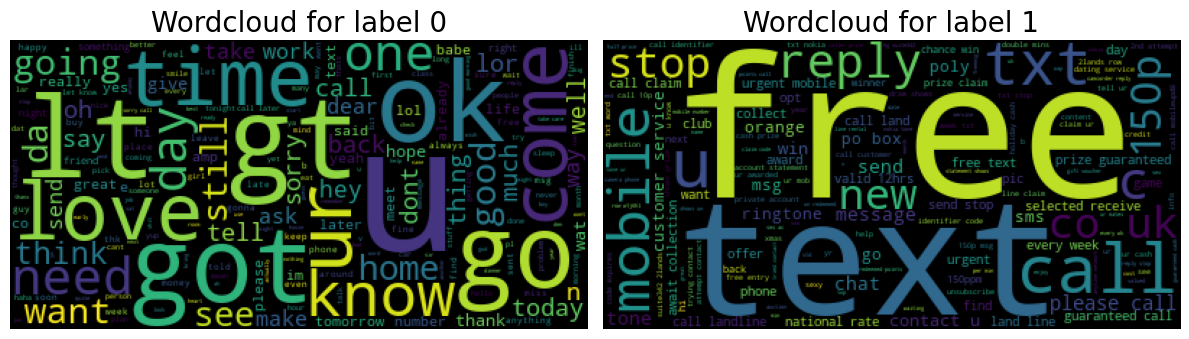

In [9]:
text_0 = ' '.join(df.loc[df.v1 == 0]['v2'])
text_1 = ' '.join(df.loc[df.v1 == 1]['v2'])

wordcloud_0 = WordCloud().generate(text_0)
wordcloud_1 = WordCloud().generate(text_1)

fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,6))

ax1.imshow(wordcloud_0)
ax1.axis("off")
ax1.set_title("Wordcloud for label 0",fontsize=20)

ax2.imshow(wordcloud_1)
ax2.axis("off")
ax2.set_title("Wordcloud for label 1",fontsize=20)

plt.tight_layout()
plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(df['v2'], df['v1'], stratify=df['v1'], 
                                                    test_size=TEST_SIZE, random_state=42)

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

In [11]:
df_train.shape[0], df_test.shape[0]

(3900, 1672)

In [12]:
def save_data(df, rootdir):
    with open(rootdir + '/features.txt', 'wt', errors='ignore') as feat_fh, \
        open(rootdir + '/labels.txt', 'wt', errors='ignore') as labl_fh:
        for idx, row in df.iterrows():
            lb = str(row['v1']) + '\n'
            ft = row['v2'].replace('\n', ' ').lower() + '\n'
            labl_fh.write(lb)
            feat_fh.write(ft)

In [13]:
save_data(df_train, TRAIN_DATA)
save_data(df_test, TEST_DATA)
df_test.to_csv(TEST_DATA + '/data_test.csv', index=False)

In [14]:
%%time
%runshell {MLTEXTCLASSIFIER} f 1 1 {path.join('model','model_CounterVectorizer_NaiveBayesClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,smoothing_param_m=1.0,smoothing_param_p=0.5

Training
minfrequency = 2
smoothing_param_m = 1
smoothing_param_p = 0.5
No of Rare Words = 3746
Fitting CountVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % done
84 % done
85 % done
86 % done
87 % done
88 % done
89 % d

c:\users\rajas.chavadekar\appdata\local\programs\python\python39\lib\subprocess.py:941: RuntimeWarning: line buffering (buffering=1) isn't supported in binary mode, the default buffer size will be used
  self.stdout = io.open(c2pread, 'rb', bufsize)


In [15]:
%%time
%runshell {MLTEXTCLASSIFIER} f 2 1 {path.join('model','model_TfidfVectorizer_NaiveBayesClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,smoothing_param_m=1.0,smoothing_param_p=0.5

Training
minfrequency = 2
smoothing_param_m = 1
smoothing_param_p = 0.5
No of Rare Words = 3746
fitting TfidfVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % done
84 % done
85 % done
86 % done
87 % done
88 % done
89 % d

In [16]:
%%time
%runshell {MLTEXTCLASSIFIER} f 1 2 {path.join('model','model_CounterVectorizer_LogisticRegressionClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,bias=0.0,epochs=15,learning_rate=0.01,l1_regularization_param=0.001,l2_regularization_param=0.0

Training
minfrequency = 2
bias = 0
epochs = 15
learning_rate = 0.01
l1_regularization_param = 0.001
l2_regularization_param = 0
No of Rare Words = 3746
Fitting CountVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % done


In [17]:
%%time
%runshell {MLTEXTCLASSIFIER} f 2 2 {path.join('model','model_TfidfVectorizer_LogisticRegressionClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,bias=0.0,epochs=15,learning_rate=0.01,l1_regularization_param=0.001,l2_regularization_param=0.0

Training
minfrequency = 2
bias = 0
epochs = 15
learning_rate = 0.01
l1_regularization_param = 0.001
l2_regularization_param = 0
No of Rare Words = 3746
fitting TfidfVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % done


In [18]:
%%time
%runshell {MLTEXTCLASSIFIER} f 1 3 {path.join('model','model_CounterVectorizer_SVCClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,bias=0.0,epochs=15,learning_rate=0.01,l1_regularization_param=0.001,l2_regularization_param=0.0

Training
minfrequency = 2
bias = 0
epochs = 15
learning_rate = 0.01
l1_regularization_param = 0.001
l2_regularization_param = 0
No of Rare Words = 3746
Fitting CountVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % done


In [19]:
%%time
%runshell {MLTEXTCLASSIFIER} f 2 3 {path.join('model','model_TfidfVectorizer_SVCClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,bias=0.0,epochs=15,learning_rate=0.01,l1_regularization_param=0.001,l2_regularization_param=0.0

Training
minfrequency = 2
bias = 0
epochs = 15
learning_rate = 0.01
l1_regularization_param = 0.001
l2_regularization_param = 0
No of Rare Words = 3746
fitting TfidfVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % done


In [20]:
%%time
%runshell {MLTEXTCLASSIFIER} f 1 5 {path.join('model','model_CounterVectorizer_RandomForestClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,num_trees=50,max_depth=5

Training
minfrequency = 2
num_trees = 50
max_depth = 5
No of Rare Words = 3746
Fitting CountVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % done
84 % done
85 % done
86 % done
87 % done
88 % done
89 % done
90 % done
91 

In [21]:
%%time
%runshell {MLTEXTCLASSIFIER} f 2 5 {path.join('model','model_TfidfVectorizer_RandomForestClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,num_trees=50,max_depth=5

Training
minfrequency = 2
num_trees = 50
max_depth = 5
No of Rare Words = 3746
fitting TfidfVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % done
84 % done
85 % done
86 % done
87 % done
88 % done
89 % done
90 % done
91 

In [22]:
%%time
%runshell {MLTEXTCLASSIFIER} f 1 6 {path.join('model','model_CounterVectorizer_GradientBoostingClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,n_trees=50,max_depth=5,learning_rate=0.01,l1_regularization_param=0.001,l2_regularization_param=0.0

Training
minfrequency = 2
n_trees = 50
max_depth = 5
learning_rate = 0.01
l1_regularization_param = 0.001
l2_regularization_param = 0
No of Rare Words = 3746
Fitting CountVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 %

In [23]:
%%time
%runshell {MLTEXTCLASSIFIER} f 2 6 {path.join('model','model_TfidfVectorizer_GradientBoostingClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,n_trees=50,max_depth=5,learning_rate=0.01,l1_regularization_param=0.001,l2_regularization_param=0.0

Training
minfrequency = 2
n_trees = 50
max_depth = 5
learning_rate = 0.01
l1_regularization_param = 0.001
l2_regularization_param = 0
No of Rare Words = 3746
fitting TfidfVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 %